# 10 - Perfect Aiming Analysis

Compares two aiming algorithms over 10 games:
- **src** (`09-Perfect_Aiming_src.py`): intercept condition checks `src_radius` only
- **tgt** (`09-Perfect_Aiming_src_tgt.py`): intercept condition checks `src_radius + tgt_radius`

Stats computed per algorithm: win rate, planet counts, fleet lifetimes, out-of-bounds ships, sun crashes.

In [ ]:
import json, math, sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

OUT_DIR = Path("10-Perfect_aiming_analysis")
OUT_DIR.mkdir(exist_ok=True)

SUN_X, SUN_Y, SUN_R = 50.0, 50.0, 10.0
BOARD_MIN, BOARD_MAX = 0.0, 100.0
AGENT_NAMES = {0: "src", 1: "tgt"}

print("Setup complete.")

Setup complete.


: 

In [ ]:
import sys, math, json, os
from pathlib import Path
from collections import defaultdict

os.chdir(r"C:\Users\trant\Documents\Programmation\Orbit Wars")
from kaggle_environments import make
from kaggle_environments.envs.orbit_wars.orbit_wars import Planet, Fleet

SUN_X, SUN_Y, SUN_R = 50.0, 50.0, 10.0
BOARD_MIN, BOARD_MAX = 0.0, 100.0
AGENT_NAMES = {0: "src", 1: "tgt"}
N_GAMES = 10
OUT_DIR = Path("10-Perfect_aiming_analysis")

def load_agent(f):
    ns = {}
    with open(f) as fp: exec(compile(fp.read(), f, "exec"), ns)
    return ns["agent"]


SRC = load_agent("09-Perfect_Aiming_src.py")
TGT = load_agent("09-Perfect_Aiming_src_tgt.py")

In [ ]:
import subprocess, sys

LOG_PATH = OUT_DIR / "game_logs.json"

if LOG_PATH.exists():
    print(f"game_logs.json already exists â€” skipping game runs.")
else:
    # kaggle_environments crashes VS Code's Jupyter kernel on Windows (OpenSpiel
    # native libs + Proactor event loop). Run via a clean miniforge subprocess instead.
    PYTHON = r"C:\Users\trant\miniforge3\python.exe"
    RUNNER = OUT_DIR / "_runner.py"
    RUNNER.write_text(r"""
import sys, math, json, os
from pathlib import Path
from collections import defaultdict

os.chdir(r"C:\Users\trant\Documents\Programmation\Orbit Wars")
from kaggle_environments import make
from kaggle_environments.envs.orbit_wars.orbit_wars import Planet, Fleet

SUN_X, SUN_Y, SUN_R = 50.0, 50.0, 10.0
BOARD_MIN, BOARD_MAX = 0.0, 100.0
AGENT_NAMES = {0: "src", 1: "tgt"}
N_GAMES = 10
OUT_DIR = Path("10-Perfect_aiming_analysis")

def load_agent(f):
    ns = {}
    with open(f) as fp: exec(compile(fp.read(), f, "exec"), ns)
    return ns["agent"]

def run_game(i, src, tgt):
    env = make("orbit_wars", debug=False); env.reset(); env.run([src, tgt])
    steps = env.steps
    rewards = [s.reward for s in steps[-1]]
    winner = 0 if rewards[0] > rewards[1] else (1 if rewards[1] > rewards[0] else -1)
    planet_counts = []
    for step in steps:
        cnt = defaultdict(int)
        for p_raw in step[0].observation.planets: cnt[Planet(*p_raw).owner] += 1
        planet_counts.append(dict(cnt))
    fleet_reg = {}
    for si, step in enumerate(steps):
        for f_raw in step[0].observation.fleets:
            f = Fleet(*f_raw)
            if f.id not in fleet_reg:
                fleet_reg[f.id] = {"owner": f.owner, "first": si, "last": si,
                                    "positions": [(f.x, f.y)], "ships": f.ships}
            else:
                fleet_reg[f.id]["last"] = si
                fleet_reg[f.id]["positions"].append((f.x, f.y))
    fleets = []
    for fid, info in fleet_reg.items():
        lt = info["last"] - info["first"] + 1
        lx, ly = info["positions"][-1]
        ds = math.hypot(lx - SUN_X, ly - SUN_Y)
        oob = any(x < BOARD_MIN or x > BOARD_MAX or y < BOARD_MIN or y > BOARD_MAX
                  for x, y in info["positions"])
        fleets.append({"game": i, "fleet_id": fid, "owner": info["owner"],
                        "agent": AGENT_NAMES[info["owner"]], "ships": info["ships"],
                        "lifetime": lt, "last_x": lx, "last_y": ly, "dist_sun_last": ds,
                        "out_of_bounds": oob, "sun_crash": ds <= SUN_R})
    return {"game": i, "n_steps": len(steps), "winner": winner,
            "winner_name": AGENT_NAMES.get(winner, "draw"), "rewards": rewards,
            "planet_counts": planet_counts, "fleets": fleets}

src = load_agent("09-Perfect_Aiming_src.py")
tgt = load_agent("09-Perfect_Aiming_src_tgt.py")
logs = []
for i in range(N_GAMES):
    g = run_game(i, src, tgt)
    logs.append(g)
    print(f"Game {i+1}: winner={g['winner_name']} steps={g['n_steps']}", flush=True)
with open(OUT_DIR / "game_logs.json", "w") as f:
    json.dump(logs, f, indent=2)
print("DONE")
""")

    print("Running 10 games via subprocess (this takes ~1 min)...")
    result = subprocess.run(
        [PYTHON, str(RUNNER)],
        capture_output=True, text=True
    )
    for line in result.stdout.splitlines():
        if any(k in line for k in ["Game", "DONE", "Error", "Traceback"]):
            print(line)
    if result.returncode != 0:
        print("STDERR:", result.stderr[-500:])
    else:
        RUNNER.unlink()  # clean up temp script
        print(f"Saved to {LOG_PATH}")

game_logs = json.loads(LOG_PATH.read_text())
print(f"Loaded {len(game_logs)} games.")

game_logs.json already exists — skipping game runs.
Loaded 10 games.


## Run 10 games and collect raw step data

In [ ]:
def run_game(game_idx):
    """Run one game (src=player0, tgt=player1) and return parsed log."""
    env = make("orbit_wars", debug=False)
    env.reset()
    env.run([SRC, TGT])
    steps = env.steps

    # Determine winner from final rewards
    final = steps[-1]
    rewards = [s.reward for s in final]
    if rewards[0] > rewards[1]:
        winner = 0
    elif rewards[1] > rewards[0]:
        winner = 1
    else:
        winner = -1  # draw

    # Collect per-step planet counts (owner -1 = neutral, 0 = src, 1 = tgt)
    planet_counts = []  # list of {player: count} per step
    for step in steps:
        obs = step[0].observation
        counts = defaultdict(int)
        for p_raw in obs.planets:
            p = Planet(*p_raw)
            counts[p.owner] += 1
        planet_counts.append(dict(counts))

    # Track fleet lifetimes, positions, and anomalies
    fleet_registry = {}  # fleet_id -> {owner, first_step, last_step, positions[]}
    for step_i, step in enumerate(steps):
        obs = step[0].observation
        for f_raw in obs.fleets:
            f = Fleet(*f_raw)
            if f.id not in fleet_registry:
                fleet_registry[f.id] = {
                    "owner": f.owner,
                    "first": step_i,
                    "last": step_i,
                    "positions": [(f.x, f.y)],
                    "ships": f.ships,
                }
            else:
                fleet_registry[f.id]["last"] = step_i
                fleet_registry[f.id]["positions"].append((f.x, f.y))

    # Classify each fleet's fate
    fleets_data = []
    for fid, info in fleet_registry.items():
        lifetime = info["last"] - info["first"] + 1
        last_x, last_y = info["positions"][-1]
        dist_sun = math.hypot(last_x - SUN_X, last_y - SUN_Y)
        out_of_bounds = any(
            x < BOARD_MIN or x > BOARD_MAX or y < BOARD_MIN or y > BOARD_MAX
            for x, y in info["positions"]
        )
        sun_crash = dist_sun <= SUN_R
        fleets_data.append({
            "game": game_idx,
            "fleet_id": fid,
            "owner": info["owner"],
            "agent": AGENT_NAMES[info["owner"]],
            "ships": info["ships"],
            "lifetime": lifetime,
            "last_x": last_x,
            "last_y": last_y,
            "dist_sun_last": dist_sun,
            "out_of_bounds": out_of_bounds,
            "sun_crash": sun_crash,
        })

    game_log = {
        "game": game_idx,
        "n_steps": len(steps),
        "winner": winner,
        "winner_name": AGENT_NAMES.get(winner, "draw"),
        "rewards": rewards,
        "planet_counts": planet_counts,
        "fleets": fleets_data,
    }
    return game_log


game_logs = []
for i in range(N_GAMES):
    print(f"Running game {i+1}/{N_GAMES}...", end=" ", flush=True)
    log = run_game(i)
    game_logs.append(log)
    print(f"done â€” winner: {log['winner_name']} ({log['n_steps']} steps)")

print("\nAll games complete.")

In [ ]:
# Persist raw logs
log_path = OUT_DIR / "game_logs.json"
with open(log_path, "w") as f:
    json.dump(game_logs, f, indent=2)
print(f"Logs saved to {log_path}")

Logs saved to 10-Perfect_aiming_analysis\game_logs.json


## Win Rate

=== Win Rate ===
  src   : 2/10 = 20%
  tgt   : 8/10 = 80%
  draw  : 0/10 = 0%


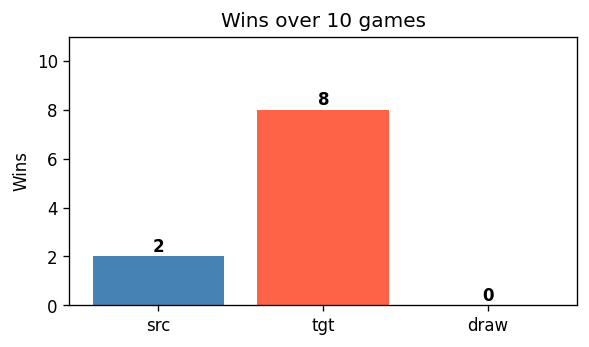

Figure saved.


In [ ]:
win_counts = defaultdict(int)
for g in game_logs:
    win_counts[g["winner_name"]] += 1

total = len(game_logs)
print("=== Win Rate ===")
for name in ["src", "tgt", "draw"]:
    n = win_counts[name]
    print(f"  {name:6s}: {n}/{total} = {n/total:.0%}")

# Bar chart
fig, ax = plt.subplots(figsize=(5, 3))
names = ["src", "tgt", "draw"]
counts = [win_counts[n] for n in names]
bars = ax.bar(names, counts, color=["steelblue", "tomato", "gray"])
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Wins over 10 games")
ax.set_ylabel("Wins")
ax.set_ylim(0, total + 1)
plt.tight_layout()
plt.savefig(OUT_DIR / "win_rate.png", dpi=120)
plt.show()
print("Figure saved.")

## Planet Ownership Over Time

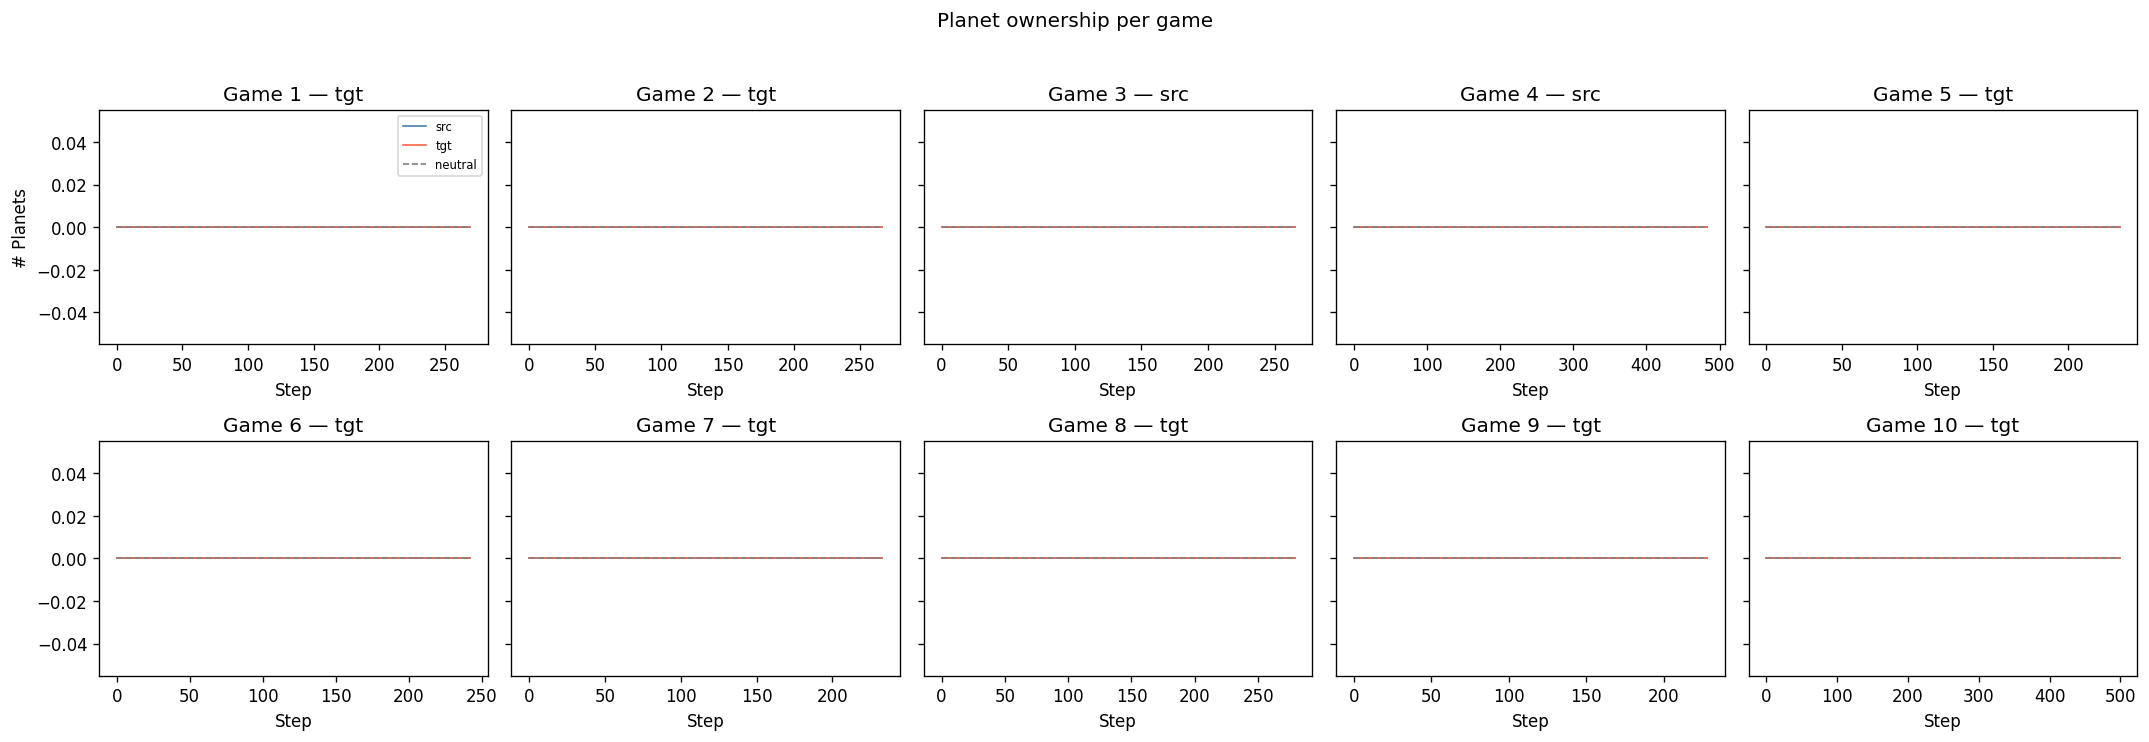

Figure saved.


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=True)
axes = axes.flatten()

for gi, g in enumerate(game_logs):
    ax = axes[gi]
    planet_counts = g["planet_counts"]
    steps_range = range(len(planet_counts))
    src_counts = [pc.get(0, 0) for pc in planet_counts]
    tgt_counts = [pc.get(1, 0) for pc in planet_counts]
    neu_counts = [pc.get(-1, 0) for pc in planet_counts]
    ax.plot(steps_range, src_counts, color="steelblue", label="src", linewidth=1)
    ax.plot(steps_range, tgt_counts, color="tomato", label="tgt", linewidth=1)
    ax.plot(steps_range, neu_counts, color="gray", label="neutral", linewidth=1, linestyle="--")
    ax.set_title(f"Game {gi+1} â€” winner: {g['winner_name']}")
    ax.set_xlabel("Step")
    if gi == 0:
        ax.set_ylabel("# Planets")
    if gi == 0:
        ax.legend(fontsize=7)

plt.suptitle("Planet ownership per game", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "planet_ownership.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved.")

## Fleet Lifetime Statistics

In [ ]:
# Build fleets DataFrame
all_fleets = []
for g in game_logs:
    all_fleets.extend(g["fleets"])
df = pd.DataFrame(all_fleets)

# Summary per agent
print("=== Fleet Lifetime (steps) ===")
for agent in ["src", "tgt"]:
    sub = df[df["agent"] == agent]["lifetime"]
    print(f"\n  {agent}")
    print(f"    count : {len(sub)}")
    print(f"    mean  : {sub.mean():.2f}")
    print(f"    std   : {sub.std():.2f}")
    print(f"    min   : {sub.min()}")
    print(f"    25%   : {sub.quantile(0.25):.1f}")
    print(f"    median: {sub.median():.1f}")
    print(f"    75%   : {sub.quantile(0.75):.1f}")
    print(f"    max   : {sub.max()}")

=== Fleet Lifetime (steps) ===

  src
    count : 2259
    mean  : 5.73
    std   : 4.32
    min   : 1
    25%   : 3.0
    median: 4.0
    75%   : 8.0
    max   : 47

  tgt
    count : 2680
    mean  : 5.74
    std   : 4.23
    min   : 1
    25%   : 3.0
    median: 4.0
    75%   : 8.0
    max   : 44


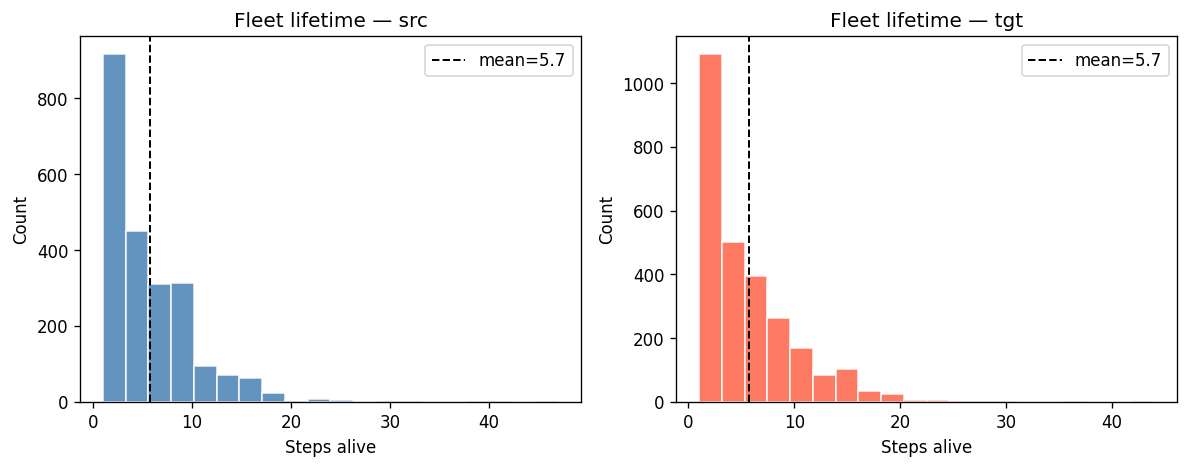

Figure saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
colors = {"src": "steelblue", "tgt": "tomato"}

for ax, agent in zip(axes, ["src", "tgt"]):
    sub = df[df["agent"] == agent]["lifetime"]
    ax.hist(sub, bins=20, color=colors[agent], edgecolor="white", alpha=0.85)
    ax.axvline(sub.mean(), color="black", linestyle="--", linewidth=1.2, label=f"mean={sub.mean():.1f}")
    ax.set_title(f"Fleet lifetime â€” {agent}")
    ax.set_xlabel("Steps alive")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "fleet_lifetime.png", dpi=120)
plt.show()
print("Figure saved.")

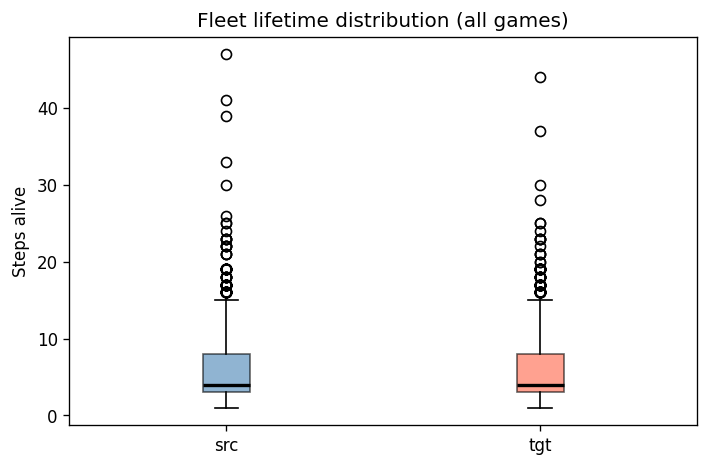

In [ ]:
# Box plot side-by-side
fig, ax = plt.subplots(figsize=(6, 4))
data = [df[df["agent"] == a]["lifetime"].values for a in ["src", "tgt"]]
bp = ax.boxplot(data, tick_labels=["src", "tgt"], patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], ["steelblue", "tomato"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title("Fleet lifetime distribution (all games)")
ax.set_ylabel("Steps alive")
plt.tight_layout()
plt.savefig(OUT_DIR / "fleet_lifetime_box.png", dpi=120)
plt.show()

## Out-of-Bounds and Sun Crashes

In [ ]:
print("=== Anomaly Detection ===")
for agent in ["src", "tgt"]:
    sub = df[df["agent"] == agent]
    n_total = len(sub)
    n_oob = sub["out_of_bounds"].sum()
    n_sun = sub["sun_crash"].sum()
    print(f"\n  {agent} ({n_total} fleets total)")
    print(f"    Out of bounds : {n_oob} ({n_oob/n_total:.1%})")
    print(f"    Sun crashes   : {n_sun} ({n_sun/n_total:.1%})")

=== Anomaly Detection ===

  src (2259 fleets total)
    Out of bounds : 0 (0.0%)
    Sun crashes   : 0 (0.0%)

  tgt (2680 fleets total)
    Out of bounds : 0 (0.0%)
    Sun crashes   : 0 (0.0%)


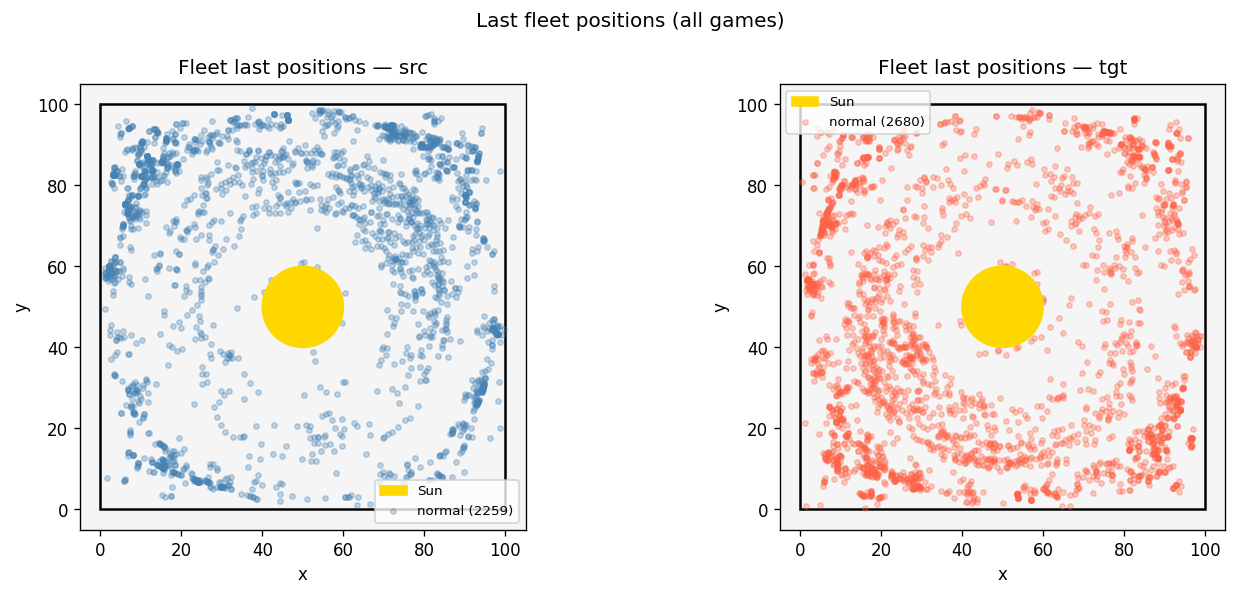

Figure saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_map = {"src": "steelblue", "tgt": "tomato"}

for ax, agent in zip(axes, ["src", "tgt"]):
    sub = df[df["agent"] == agent]
    normal = sub[~sub["out_of_bounds"] & ~sub["sun_crash"]]
    oob = sub[sub["out_of_bounds"]]
    sun = sub[sub["sun_crash"]]

    ax.set_facecolor("#f5f5f5")

    # Board boundary
    board = patches.Rectangle((0, 0), 100, 100, linewidth=1.5,
                                edgecolor="black", facecolor="none")
    ax.add_patch(board)

    # Sun
    sun_circle = plt.Circle((SUN_X, SUN_Y), SUN_R, color="gold", zorder=5, label="Sun")
    ax.add_patch(sun_circle)

    # Normal last positions
    if len(normal):
        ax.scatter(normal["last_x"], normal["last_y"], s=10,
                   color=colors_map[agent], alpha=0.3, label=f"normal ({len(normal)})")
    # OOB
    if len(oob):
        ax.scatter(oob["last_x"], oob["last_y"], s=40, marker="x",
                   color="red", zorder=10, label=f"out-of-bounds ({len(oob)})")
    # Sun crash
    if len(sun):
        ax.scatter(sun["last_x"], sun["last_y"], s=60, marker="*",
                   color="darkorange", zorder=10, label=f"sun crash ({len(sun)})")

    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    ax.set_aspect("equal")
    ax.set_title(f"Fleet last positions â€” {agent}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Last fleet positions (all games)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fleet_positions.png", dpi=120)
plt.show()
print("Figure saved.")

## Anomaly Detail Table

In [ ]:
anomalies = df[(df["out_of_bounds"]) | (df["sun_crash"])].copy()
if anomalies.empty:
    print("No anomalies detected across all games.")
else:
    display_cols = ["game", "agent", "fleet_id", "ships", "lifetime",
                    "last_x", "last_y", "dist_sun_last", "out_of_bounds", "sun_crash"]
    display(anomalies[display_cols].sort_values(["agent", "game"]).reset_index(drop=True))
    anomalies.to_csv(OUT_DIR / "anomalies.csv", index=False)
    print(f"Anomalies saved to {OUT_DIR / 'anomalies.csv'}")

No anomalies detected across all games.


## Summary Table

In [ ]:
rows = []
for agent in ["src", "tgt"]:
    sub = df[df["agent"] == agent]["lifetime"]
    n_oob = df[(df["agent"] == agent) & df["out_of_bounds"]].shape[0]
    n_sun = df[(df["agent"] == agent) & df["sun_crash"]].shape[0]
    n_wins = win_counts[agent]
    rows.append({
        "agent": agent,
        "wins": n_wins,
        "win_rate": f"{n_wins/total:.0%}",
        "fleets_total": len(sub),
        "lifetime_mean": round(sub.mean(), 2),
        "lifetime_std": round(sub.std(), 2),
        "lifetime_min": int(sub.min()),
        "lifetime_max": int(sub.max()),
        "out_of_bounds": n_oob,
        "sun_crashes": n_sun,
    })

summary_df = pd.DataFrame(rows).set_index("agent")
display(summary_df)
summary_df.to_csv(OUT_DIR / "summary.csv")
print(f"Summary saved to {OUT_DIR / 'summary.csv'}")

       wins win_rate  fleets_total  lifetime_mean  lifetime_std  lifetime_min  lifetime_max  out_of_bounds  sun_crashes
agent                                                                                                                  
src       2      20%          2259           5.73          4.32             1            47              0            0
tgt       8      80%          2680           5.74          4.23             1            44              0            0

Summary saved to 10-Perfect_aiming_analysis\summary.csv


In [ ]:
import json, math, sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

OUT_DIR = Path("10-Perfect_aiming_analysis")
OUT_DIR.mkdir(exist_ok=True)

SUN_X, SUN_Y, SUN_R = 50.0, 50.0, 10.0
BOARD_MIN, BOARD_MAX = 0.0, 100.0
AGENT_NAMES = {0: "src", 1: "tgt"}

print("Setup complete.")